# Milestones 1 & 2 — Naive loop and KV cache

Thin driver. All logic lives in `engine/`.

In [1]:
# Colab only — skip if running locally in the repo.
!git clone https://github.com/Jayaprakash-030/tiny-inference-engine.git
%cd tiny-inference-engine
!pip install -q -e .

Cloning into 'tiny-inference-engine'...
remote: Enumerating objects: 126, done.
remote: Counting objects: 100% (126/126), done.
remote: Compressing objects: 100% (92/92), done.
remote: Total 126 (delta 72), reused 85 (delta 31), pack-reused 0 (from 0)
Receiving objects: 100% (126/126), 303.40 KiB | 6.07 MiB/s, done.
Resolving deltas: 100% (72/72), done.
/content/tiny-inference-engine
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for tiny-inference-engine (pyproject.toml) ... done


In [2]:
from engine import load
from engine.naive import measure_naive, warmup
from engine.cached import check_matches_naive, measure_cached
from engine.prompts import SHORT, LONG
from engine.results import report, save

rt = load()
rt.describe()

/usr/local/lib/python3.13/dist-packages/huggingface_hub/utils/_auth.py:138: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
  warnings.warn(f"\nError while fetching `HF_TOKEN` secret value from your vault: '{str(e)}'.")


config.json:   0%|          | 0.00/726 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/9.73k [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/2.78M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

...

model.safetensors: reconstructing file:   0%|          |  0.00B / 1.50GB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/311 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/239 [00:00<?, ?B/s]

model : Qwen/Qwen3-0.6B
device: cuda
dtype : torch.float16
layers: 28
gpu   : Tesla T4


In [3]:
MAX_NEW = 400
warmup(rt, SHORT)
print("warmup done")

warmup done


## Milestone 1 — baseline

In [4]:
m1 = [
    report(measure_naive(rt, "short_prompt", SHORT, MAX_NEW)),
    report(measure_naive(rt, "long_prompt", LONG, MAX_NEW)),
]
save(m1)

--- short_prompt ---
             milestone: 1
                 label: short_prompt
         prompt_tokens: 5
      generated_tokens: 400
         first_step_ms: 50.21
          last_step_ms: 70.69
        median_step_ms: 49.19
        tokens_per_sec: 18.88
           peak_mem_gb: 1.448
curve (every 16th step): [50.2, 47.1, 48.5, 46.9, 47.4, 47.4, 47.2, 48.3, 46.7, 61.9, 59.9, 53.9, 60.6, 47.8, 48.6, 49.0, 47.5, 48.6, 45.9, 53.9, 51.7, 50.9, 53.8, 55.9, 67.7]

--- long_prompt ---
             milestone: 1
                 label: long_prompt
         prompt_tokens: 227
      generated_tokens: 400
         first_step_ms: 59.72
          last_step_ms: 110.01
        median_step_ms: 71.21
        tokens_per_sec: 13.69
           peak_mem_gb: 1.585
curve (every 16th step): [59.7, 47.3, 46.1, 63.5, 46.4, 50.7, 50.0, 48.9, 55.3, 56.3, 63.0, 64.4, 68.9, 71.8, 79.6, 75.5, 81.4, 81.6, 89.7, 93.7, 98.0, 100.1, 102.6, 105.2, 107.5]

appended 2 results to benchmarks/results.json


Flat while short (launch-bound), then linear growth. Linear per step means
quadratic in total — that slope is the missing cache.

## Milestone 2 — KV cache

In [5]:
assert check_matches_naive(rt, SHORT), "cache diverged"
assert check_matches_naive(rt, LONG), "cache diverged"

token-identical: True
token-identical: True


In [6]:
m2 = [
    report(measure_cached(rt, "short_prompt", SHORT, MAX_NEW)),
    report(measure_cached(rt, "long_prompt", LONG, MAX_NEW)),
]
save(m2)

--- short_prompt ---
             milestone: 2
                 label: short_prompt
         prompt_tokens: 5
      generated_tokens: 400
            prefill_ms: 52.64
      decode_median_ms: 43.24
         decode_p95_ms: 66.61
       decode_first_ms: 41.81
        decode_last_ms: 42.05
        tokens_per_sec: 21.21
           peak_mem_gb: 1.261
curve (every 16th step): [41.8, 55.0, 57.1, 42.0, 42.1, 42.1, 42.3, 41.0, 45.4, 41.6, 42.7, 43.1, 42.2, 42.9, 56.5, 42.1, 45.1, 57.1, 56.6, 66.9, 41.7, 45.4, 42.6, 42.3, 41.9]

--- long_prompt ---
             milestone: 2
                 label: long_prompt
         prompt_tokens: 227
      generated_tokens: 400
            prefill_ms: 49.64
      decode_median_ms: 43.18
         decode_p95_ms: 59.28
       decode_first_ms: 46.16
        decode_last_ms: 48.37
        tokens_per_sec: 21.91
           peak_mem_gb: 1.319
curve (every 16th step): [46.2, 44.1, 41.7, 58.1, 43.0, 42.4, 42.5, 42.5, 42.5, 58.6, 56.3, 54.1, 43.0, 42.5, 43.4, 44.5, 43.5,

## Comparison

In [7]:
header = f"{'':<14}{'naive tok/s':>13}{'cached tok/s':>14}{'speedup':>10}"
print(header)
print("-" * len(header))
for a, b in zip(m1, m2):
    print(f"{a['label']:<14}{a['tokens_per_sec']:>13}{b['tokens_per_sec']:>14}"
          f"{b['tokens_per_sec'] / a['tokens_per_sec']:>9.1f}x")

                naive tok/s  cached tok/s   speedup
---------------------------------------------------
short_prompt          18.88         21.21      1.1x
long_prompt           13.69         21.91      1.6x


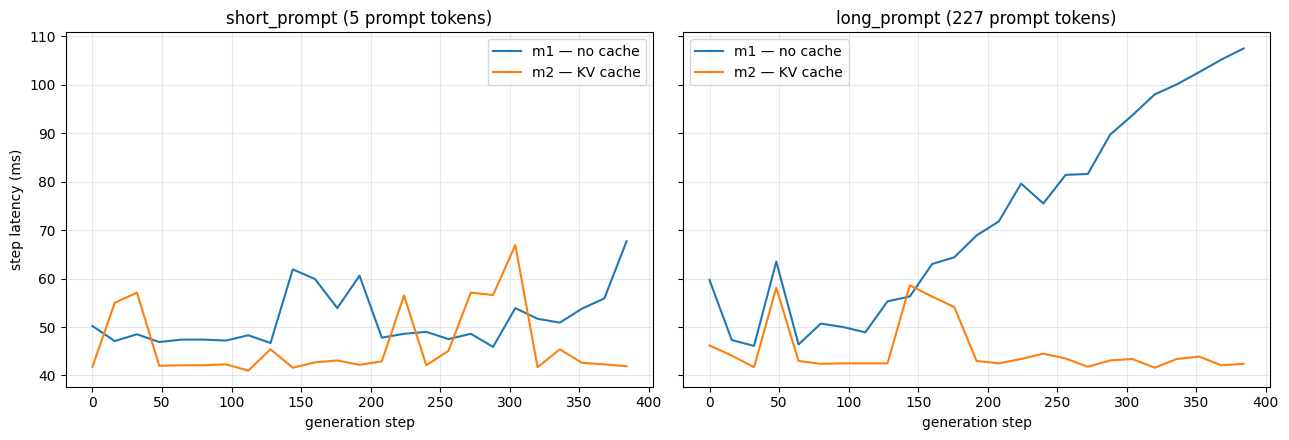

In [ ]:
import matplotlib.pyplot as plt
from pathlib import Path

Path("benchmarks/plots").mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for ax, a, b in zip(axes, m1, m2):
    ax.plot(range(0, len(a["curve"]) * 16, 16), a["curve"], label="m1 — no cache")
    ax.plot(range(0, len(b["curve"]) * 16, 16), b["curve"], label="m2 — KV cache")
    ax.set_title(f"{a['label']} ({a['prompt_tokens']} prompt tokens)")
    ax.set_xlabel("generation step")
    ax.grid(alpha=0.3)
    ax.legend()
axes[0].set_ylabel("step latency (ms)")
plt.tight_layout()
plt.savefig("benchmarks/plots/m1_vs_m2.png", dpi=140)
plt.show()
